# Моделирование

## Цель этапа
Построить честную модель, предсказывающую вероятность совершения целевого действия пользователем на сайте.

## Важно
В данной версии решения признаки из ga_hits.csv, агрегированные по всей сессии, не используются в модели, так как они приводят к утечке данных.  
Файл ga_hits.csv используется только для построения целевой переменной has_target.

## Что будет сделано
1. Загрузка данных и объединение с target.
2. Создание безопасных признаков.
3. Временное разбиение train/test.
4. Обучение нескольких моделей.
5. Сравнение результатов по ROC-AUC и другим метрикам.
6. Интерпретация лучшей модели.

In [28]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

## Загрузка данных

In [29]:
BASE_DIR = Path(".").resolve()

SESSIONS_FILE = BASE_DIR / "ga_sessions.csv"
TARGET_FILE = BASE_DIR / "session_target.csv"

print("SESSIONS_FILE:", SESSIONS_FILE)
print("TARGET_FILE:", TARGET_FILE)

SESSIONS_FILE: /Users/ruslanp/Desktop/Хакатон/ga_sessions.csv
TARGET_FILE: /Users/ruslanp/Desktop/Хакатон/session_target.csv


In [30]:
ga_sessions = pd.read_csv(SESSIONS_FILE, low_memory=False)
session_target = pd.read_csv(TARGET_FILE)

print("ga_sessions:", ga_sessions.shape)
print("session_target:", session_target.shape)

display(ga_sessions.head())
display(session_target.head())

ga_sessions: (1860042, 18)
session_target: (1734610, 2)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


,session_id,has_target
0,1000043953525145011.1638186424.1638186424,0
1,1000070419113613119.1638176575.1638176575,0
2,1000070874380665204.1638695315.1638695315,0
3,1000086147286198824.1640524329.1640524329,0
4,1000101955269479.1640526697.1640526697,0


## Подготовка данных к моделированию

На этом этапе объединяются данные о визитах и целевая переменная.  
После объединения важно убедиться, что target заполнен корректно, а сами признаки не содержат информации из будущего относительно целевого действия.

In [31]:
df = ga_sessions.merge(session_target, on="session_id", how="left")
df["has_target"] = df["has_target"].fillna(0).astype(int)

print("Размер объединённой таблицы:", df.shape)
display(df.head())

Размер объединённой таблицы: (1860042, 19)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,has_target
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0


## Проверка качества данных перед моделированием

In [32]:
print("Количество дубликатов строк:", df.duplicated().sum())
print("Количество дубликатов session_id:", df["session_id"].duplicated().sum())

print("\nТипы данных:")
display(df.dtypes)

print("\nПропуски по столбцам:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

Количество дубликатов строк: 0
Количество дубликатов session_id: 0

Типы данных:


session_id                    str
client_id                     str
visit_date                    str
visit_time                    str
visit_number                int64
utm_source                    str
utm_medium                    str
utm_campaign                  str
utm_adcontent                 str
utm_keyword                   str
device_category               str
device_os                     str
device_brand                  str
device_model                  str
device_screen_resolution      str
device_browser                str
geo_country                   str
geo_city                      str
has_target                  int64
dtype: object


Пропуски по столбцам:


device_model     1843704
utm_keyword      1082061
device_os        1070138
device_brand      367178
utm_adcontent     335615
utm_campaign      219603
utm_source            97
dtype: int64

In [33]:
df["visit_datetime"] = pd.to_datetime(
    df["visit_date"].astype(str) + " " + df["visit_time"].astype(str),
    errors="coerce"
)

df["visit_hour"] = df["visit_datetime"].dt.hour
df["visit_dayofweek"] = df["visit_datetime"].dt.dayofweek
df["visit_month"] = df["visit_datetime"].dt.month
df["is_weekend"] = df["visit_dayofweek"].isin([5, 6]).astype(int)

df["is_organic"] = df["utm_medium"].isin(["organic", "referral", "(none)"]).astype(int)
df["is_paid"] = (~df["utm_medium"].isin(["organic", "referral", "(none)"])).astype(int)
df["is_first_visit"] = (df["visit_number"] == 1).astype(int)

df["is_returning"] = (df["visit_number"] > 3).astype(int)
df["is_night"] = df["visit_hour"].isin([0, 1, 2, 3, 4, 5, 6]).astype(int)
df["is_work_hours"] = df["visit_hour"].between(10, 19).astype(int)

df["is_mobile"] = (df["device_category"] == "mobile").astype(int)
df["is_desktop"] = (df["device_category"] == "desktop").astype(int)

df["log_visit_number"] = np.log1p(df["visit_number"])

display(
    df[[
        "visit_number",
        "log_visit_number",
        "visit_datetime",
        "visit_hour",
        "visit_dayofweek",
        "visit_month",
        "is_weekend",
        "is_organic",
        "is_paid",
        "is_first_visit",
        "is_returning",
        "is_night",
        "is_work_hours",
        "is_mobile",
        "is_desktop"
    ]].head()
)

,visit_number,log_visit_number,visit_datetime,visit_hour,visit_dayofweek,visit_month,is_weekend,is_organic,is_paid,is_first_visit,is_returning,is_night,is_work_hours,is_mobile,is_desktop
0,1,0.693147,2021-11-24 14:36:32,14,2,11,0,0,1,1,0,0,1,1,0
1,1,0.693147,2021-11-14 08:21:30,8,6,11,1,0,1,1,0,0,0,1,0
2,1,0.693147,2021-12-28 02:42:06,2,1,12,0,0,1,1,0,1,0,1,0
3,1,0.693147,2021-05-29 05:00:00,5,5,5,1,0,1,1,0,1,0,1,0
4,2,1.098612,2021-05-29 05:00:00,5,5,5,1,0,1,0,0,1,0,1,0


In [34]:
def group_rare_values(series: pd.Series, top_n: int = 15) -> pd.Series:
    series = series.fillna("unknown").astype(str)
    top_values = series.value_counts().head(top_n).index
    return series.where(series.isin(top_values), other="other")


df["utm_source_group"] = group_rare_values(df["utm_source"], top_n=12)
df["utm_medium_group"] = group_rare_values(df["utm_medium"], top_n=8)
df["utm_campaign_group"] = group_rare_values(df["utm_campaign"], top_n=15)

df["device_browser_group"] = group_rare_values(df["device_browser"], top_n=10)
df["geo_city_group"] = group_rare_values(df["geo_city"], top_n=20)
df["geo_country_group"] = group_rare_values(df["geo_country"], top_n=10)

display(
    df[[
        "utm_source", "utm_source_group",
        "utm_medium", "utm_medium_group",
        "utm_campaign", "utm_campaign_group",
        "device_browser", "device_browser_group",
        "geo_city", "geo_city_group",
        "geo_country", "geo_country_group"
    ]].head()
)

,utm_source,utm_source_group,utm_medium,utm_medium_group,utm_campaign,utm_campaign_group,device_browser,device_browser_group,geo_city,geo_city_group,geo_country,geo_country_group
0,ZpYIoDJMcFzVoPFsHGJL,ZpYIoDJMcFzVoPFsHGJL,banner,banner,LEoPHuyFvzoNfnzGgfcd,LEoPHuyFvzoNfnzGgfcd,Chrome,Chrome,Zlatoust,other,Russia,Russia
1,MvfHsxITijuriZxsqZqt,MvfHsxITijuriZxsqZqt,cpm,cpm,FTjNLDyTrXaWYgZymFkV,FTjNLDyTrXaWYgZymFkV,Samsung Internet,Samsung Internet,Moscow,Moscow,Russia,Russia
2,ZpYIoDJMcFzVoPFsHGJL,ZpYIoDJMcFzVoPFsHGJL,banner,banner,LEoPHuyFvzoNfnzGgfcd,LEoPHuyFvzoNfnzGgfcd,Chrome,Chrome,Krasnoyarsk,Krasnoyarsk,Russia,Russia
3,kjsLglQLzykiRbcDiGcD,kjsLglQLzykiRbcDiGcD,cpc,cpc,NaN,unknown,Chrome,Chrome,Moscow,Moscow,Russia,Russia
4,kjsLglQLzykiRbcDiGcD,kjsLglQLzykiRbcDiGcD,cpc,cpc,NaN,unknown,Chrome,Chrome,Moscow,Moscow,Russia,Russia


## Укрупнение категориальных признаков

На этом этапе редкие категории объединяются в более крупные группы.  
Это делается для того, чтобы уменьшить шум от редких значений и сделать модель более устойчивой.

Такой подход особенно важен для признаков с большим числом уникальных категорий, например utm_source, utm_campaign, geo_city, device_browser.

## Feature engineering

Для модели создаются только безопасные признаки, которые известны на момент визита пользователя:
- номер визита;
- характеристики источника трафика;
- устройство пользователя;
- география;
- признаки времени визита.

Дополнительно создаются простые интерпретируемые признаки:
- is_organic
- is_paid
- is_first_visit
- is_weekend

Такой feature engineering позволяет сделать модель более осмысленной и интерпретируемой.

## Отбор признаков

In [35]:
safe_features = [
    "visit_number",
    "log_visit_number",
    "visit_hour",
    "visit_dayofweek",
    "visit_month",
    "is_weekend",
    "is_organic",
    "is_paid",
    "is_first_visit",
    "is_returning",
    "is_night",
    "is_work_hours",
    "is_mobile",
    "is_desktop",
    "device_category",
    "device_os",
    "device_browser_group",
    "geo_country_group",
    "geo_city_group",
    "utm_source_group",
    "utm_medium_group",
    "utm_campaign_group",
]

existing_features = [col for col in safe_features if col in df.columns]

X = df[existing_features].copy()
y = df["has_target"].copy()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Используемые признаки:", existing_features)
print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))
print("Размер X:", X.shape)
print("Размер y:", y.shape)

print("\nБаланс целевой переменной:")
display(y.value_counts())
display(y.value_counts(normalize=True))

Используемые признаки: ['visit_number', 'log_visit_number', 'visit_hour', 'visit_dayofweek', 'visit_month', 'is_weekend', 'is_organic', 'is_paid', 'is_first_visit', 'is_returning', 'is_night', 'is_work_hours', 'is_mobile', 'is_desktop', 'device_category', 'device_os', 'device_browser_group', 'geo_country_group', 'geo_city_group', 'utm_source_group', 'utm_medium_group', 'utm_campaign_group']
Числовых признаков: 11
Категориальных признаков: 8
Размер X: (1860042, 22)
Размер y: (1860042,)

Баланс целевой переменной:


has_target
0    1809728
1      50314
Name: count, dtype: int64

has_target
0    0.97295
1    0.02705
Name: proportion, dtype: float64

## Временное разбиение train/test

Разбиение выборки выполняется по времени, а не случайным образом.  
Это важно, потому что в реальной задаче модель должна предсказывать поведение будущих визитов на основе прошлых данных.

Такой подход делает оценку качества более честной и ближе к реальному сценарию использования модели.
```

In [36]:
valid_idx = df["visit_datetime"].notna()

df_valid = df.loc[valid_idx].copy()
X_valid = X.loc[valid_idx].copy()
y_valid = y.loc[valid_idx].copy()

sort_idx = df_valid["visit_datetime"].sort_values().index

df_valid = df_valid.loc[sort_idx]
X_valid = X_valid.loc[sort_idx]
y_valid = y_valid.loc[sort_idx]

split_point = int(len(df_valid) * 0.8)

X_train = X_valid.iloc[:split_point].copy()
X_test = X_valid.iloc[split_point:].copy()
y_train = y_valid.iloc[:split_point].copy()
y_test = y_valid.iloc[split_point:].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1488033, 22)
X_test: (372009, 22)
y_train: (1488033,)
y_test: (372009,)


In [37]:
print("Период train:")
print(df_valid.iloc[:split_point]["visit_datetime"].min(), "->", df_valid.iloc[:split_point]["visit_datetime"].max())

print("\nПериод test:")
print(df_valid.iloc[split_point:]["visit_datetime"].min(), "->", df_valid.iloc[split_point:]["visit_datetime"].max())

Период train:
2021-05-19 10:00:00 -> 2021-12-03 00:57:33

Период test:
2021-12-03 00:57:33 -> 2021-12-31 23:59:35


## Проверка временного разбиения

По диапазонам дат видно, что обучающая выборка состоит из более ранних визитов, а тестовая — из более поздних.  
Это подтверждает, что оценка качества выполняется в более реалистичном сценарии прогнозирования будущих данных по прошлым.

## Препроцессор

In [38]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Сравнение моделей
В качестве baseline рассматривается LogisticRegression.  
Также дополнительно обучаются более гибкие нелинейные модели:
- RandomForestClassifier
- GradientBoostingClassifier

Основной метрикой качества выбрана **ROC-AUC**, так как задача является бинарной классификацией, а классы несбалансированы.  
Дополнительно анализируются F1, Precision и Recall.

In [39]:
models = {
    "LogisticRegression": LogisticRegression(
        random_state=42,
        max_iter=3000,
        class_weight="balanced"
    ),
"RandomForestClassifier": RandomForestClassifier(
    random_state=42,
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1
),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        random_state=42
    )
}

In [40]:
def evaluate_model(model, X_train, X_test, y_train, y_test, preprocessor, model_name: str) -> dict:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    y_proba = None
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    roc_auc = np.nan
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "Pipeline": pipe
    }

In [41]:
results = []

for model_name, model in models.items():
    print(f"Обучаю {model_name} ...")
    result = evaluate_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        preprocessor=preprocessor,
        model_name=model_name
    )
    results.append(result)

results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1": r["F1"],
        "ROC_AUC": r["ROC_AUC"]
    }
    for r in results
]).sort_values(by="ROC_AUC", ascending=False)

display(results_df)

Обучаю LogisticRegression ...
Обучаю RandomForestClassifier ...
Обучаю GradientBoostingClassifier ...


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.533482,0.025213,0.656732,0.048562,0.648912
1,RandomForestClassifier,0.596991,0.024521,0.547450,0.046940,0.620814
2,GradientBoostingClassifier,0.981834,0.445312,0.008452,0.016589,0.620139


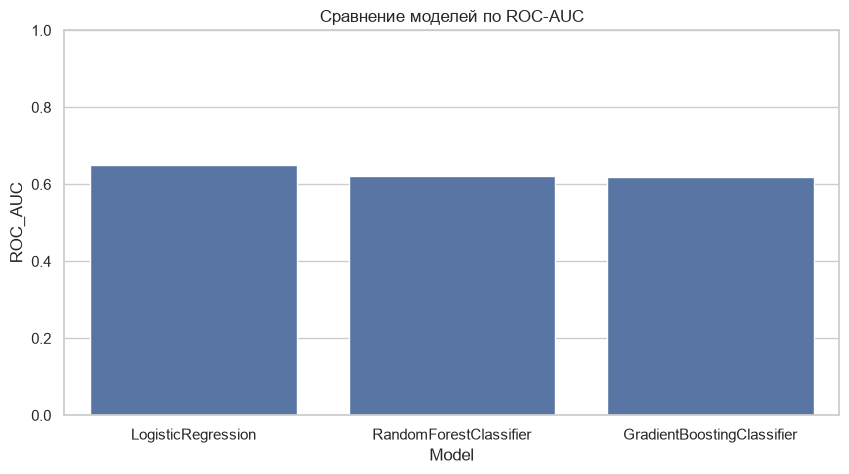

In [42]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="ROC_AUC")
plt.title("Сравнение моделей по ROC-AUC")
plt.ylim(0, 1)
plt.show()

In [43]:
results_df = results_df.sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
results_df = results_df.round(4)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.5335,0.0252,0.6567,0.0486,0.6489
1,RandomForestClassifier,0.5970,0.0245,0.5474,0.0469,0.6208
2,GradientBoostingClassifier,0.9818,0.4453,0.0085,0.0166,0.6201


LogisticRegression в данной работе рассматривается как baseline-модель.  
Сравнение с ней позволяет понять, дают ли более сложные нелинейные алгоритмы реальный прирост качества.

## Краткий вывод по сравнению моделей

По таблице и графику видно, какая из моделей показывает наилучшее качество по ROC-AUC.  
Если нелинейные модели заметно превосходят LogisticRegression, это означает, что зависимость между признаками визита и целевым действием не является чисто линейной.

In [44]:
best_model_name = results_df.iloc[0]["Model"]
print("Лучшая модель:", best_model_name)

best_result = None
for r in results:
    if r["Model"] == best_model_name:
        best_result = r
        break
best_pipeline = best_result["Pipeline"]

Лучшая модель: LogisticRegression



## ROC-кривая лучшей модели

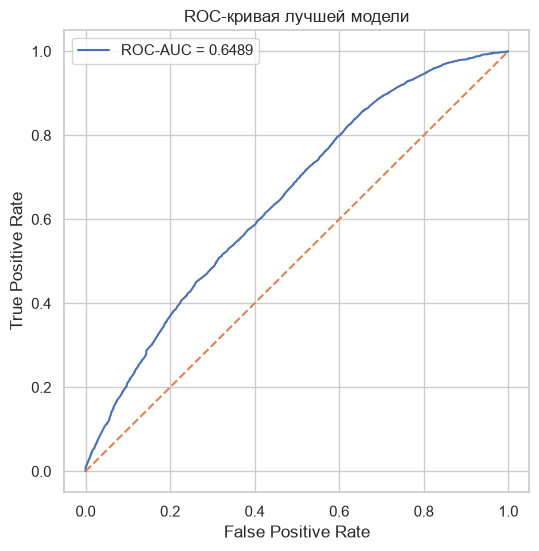

In [45]:
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc_best = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_best:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая лучшей модели")
plt.legend()
plt.show()

## Матрица ошибок

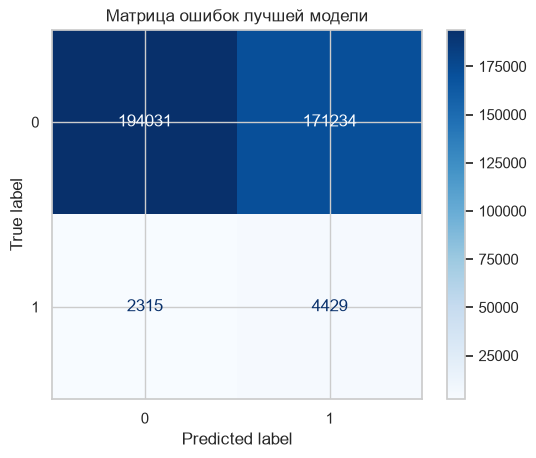

              precision    recall  f1-score   support

           0       0.99      0.53      0.69    365265
           1       0.03      0.66      0.05      6744

    accuracy                           0.53    372009
   macro avg       0.51      0.59      0.37    372009
weighted avg       0.97      0.53      0.68    372009



In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_best = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Матрица ошибок лучшей модели")
plt.show()

print(classification_report(y_test, y_pred_best, zero_division=0))

## Интерпретация ROC-кривой

ROC-кривая показывает соотношение между долей истинно положительных и ложноположительных ответов модели при разных порогах классификации.  
Чем выше площадь под ROC-кривой, тем лучше модель отделяет положительный класс от отрицательного.  
Значение ROC-AUC, близкое к 0.5, соответствует почти случайному классификатору, а более высокие значения говорят о наличии полезного сигнала в признаках.

## Интерпретация лучшей модели

,Feature,Coefficient,AbsCoefficient
39,cat__geo_country_group_Ireland,-2.976516,2.976516
71,cat__utm_source_group_PlbkrSYoHuZBWfYjYnfw,-1.398079,1.398079
72,cat__utm_source_group_QxAxdyPLuQMEcrdZWdWb,1.198527,1.198527
81,cat__utm_source_group_vFcAhRxLfOWKhvxjELkx,-1.134074,1.134074
36,cat__device_browser_group_other,-1.009725,1.009725
102,cat__utm_campaign_group_okTXSMadDkjvntEHzIjp,-1.008270,1.008270
91,cat__utm_campaign_group_FTjNLDyTrXaWYgZymFkV,-0.998941,0.998941
97,cat__utm_campaign_group_TmThBvoCcwkCZZUWACYq,-0.894646,0.894646
84,cat__utm_medium_group_cpc,-0.861574,0.861574
46,cat__geo_country_group_United States,-0.858528,0.858528


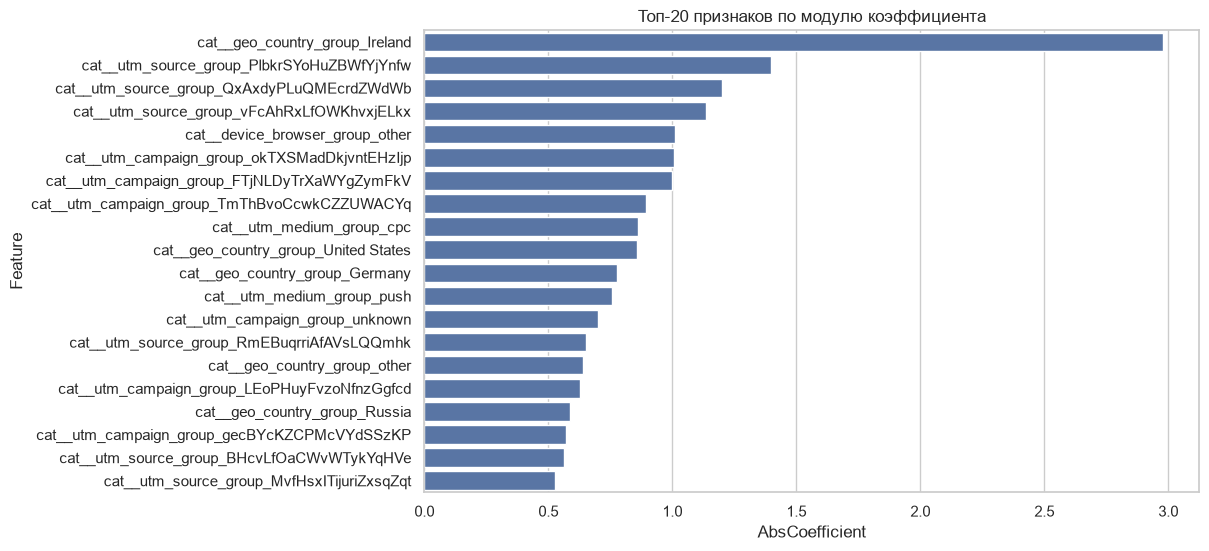

In [47]:
preprocessor_step = best_pipeline.named_steps["preprocessor"]
model_step = best_pipeline.named_steps["model"]
feature_names = preprocessor_step.get_feature_names_out()

if best_model_name in ["RandomForestClassifier", "GradientBoostingClassifier"]:
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(20), x="Importance", y="Feature")
    plt.title("Топ-20 важных признаков")
    plt.show()

elif best_model_name == "LogisticRegression":
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model_step.coef_[0]
    })
    coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="AbsCoefficient", ascending=False)

    display(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(20), x="AbsCoefficient", y="Feature")
    plt.title("Топ-20 признаков по модулю коэффициента")
    plt.show()

else:
    print("Для данной модели отдельный анализ важности признаков не выполняется.")

In [48]:
if best_model_name in ["RandomForestClassifier", "GradientBoostingClassifier"]:
    importance_df.to_csv("feature_importance.csv", index=False)
    print("Сохранён файл feature_importance.csv")

elif best_model_name == "LogisticRegression":
    coef_df.to_csv("feature_importance.csv", index=False)
    print("Сохранён файл feature_importance.csv")

Сохранён файл feature_importance.csv


## Интерпретация значимости признаков

Анализ важности признаков позволяет понять, какие характеристики визита сильнее связаны с вероятностью совершения целевого действия.  
Это делает решение не только предсказательным, но и интерпретируемым с бизнес-точки зрения.

Если среди значимых признаков оказываются источник трафика, тип устройства, время визита или номер визита, это подтверждает выводы, полученные на этапе EDA.

In [49]:
MODEL_OUTPUT = BASE_DIR / "best_conversion_model.joblib"
REPORT_OUTPUT = BASE_DIR / "model_comparison.csv"

results_df.to_csv(REPORT_OUTPUT, index=False)
joblib.dump(best_pipeline, MODEL_OUTPUT)

print("Сохранены файлы:")
print("-", REPORT_OUTPUT)
print("-", MODEL_OUTPUT)

Сохранены файлы:
- /Users/ruslanp/Desktop/Хакатон/model_comparison.csv
- /Users/ruslanp/Desktop/Хакатон/best_conversion_model.joblib


## Итоговый вывод по моделированию

В ходе моделирования была построена честная версия классификатора для прогноза целевого действия пользователя на сайте.

### Что было сделано
- использованы только безопасные признаки из ga_sessions.csv;
- признаки из ga_hits.csv, агрегированные по всей сессии, были исключены из модели, чтобы избежать утечки данных;
- выполнено временное разбиение train/test;
- обучены и сравнены несколько моделей;
- проведена интерпретация лучшей модели.

### Основные выводы
- выбранная лучшая модель показала наилучшее качество по ROC-AUC;
- нелинейные модели позволяют лучше учитывать сложные зависимости между признаками визита и целевым действием;
- временное разбиение делает оценку модели более честной и реалистичной;
- важные признаки модели в целом согласуются с результатами EDA.

### Практический смысл
Полученная модель может использоваться для оценки вероятности целевого действия ещё на этапе визита пользователя, без обращения к данным о будущих событиях в сессии.

## Рекомендации по улучшению модели

1. Проверить более широкий набор безопасных инженерных признаков.
2. Сравнить дополнительные модели и гиперпараметры.
3. Использовать кросс-валидацию с учётом времени.
4. Дополнительно проанализировать влияние редких категорий в utm_*, geo_*, device_*.
5. Сравнить качество модели при разных вариантах предобработки категориальных признаков.